## 1. 라이브러리 임포트 및 초기 설정


In [1]:
import os
import glob
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# 주피터 노트북 환경용 시각화 옵션
%matplotlib inline

# config.py 파일이 환경 내에 있다고 가정합니다.
# config.py가 없는 경우 아래 주석을 해제하고 변수를 직접 정의해 사용하세요.
from config import RIGHT_HAND_KEYS, CHANNELS

# RIGHT_HAND_KEYS = {'y': 11, 'u': 12, 'i': 13, 'o': 14, 'p': 15, '[': 16, ']': 17, '\\': 18, 'h': 21, 'j': 22, 'k': 23, 'l': 24, ';': 25, "'": 26, 'n': 31, 'm': 32, ',': 33, '.': 34, '/': 35}
# CHANNELS = 8


## 2. 하이퍼파라미터 (Hyperparameters)
하이퍼파라미터 변수들을 한 곳에 모아 쉽게 실험하고 수정할 수 있도록 분리하였습니다.


In [2]:
# ==============================================================================
# 하이퍼파라미터 설정 (Hyperparameters)
# ==============================================================================
# 윈도우 및 채널 설정
WINDOW_SIZE  = 100
PRE_EVENT    = 40
POST_EVENT   = WINDOW_SIZE - PRE_EVENT
NUM_CHANNELS = CHANNELS
BATCH_SIZE   = 64

# 모델 훈련 (Train) 설정
EPOCHS       = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

# 스케줄러(Scheduler) 파라미터 (CosineAnnealingWarmRestarts)
T_0          = 15
T_MULT       = 2
ETA_MIN      = 1e-5

# 조기 종료(Early Stopping) 설정
PATIENCE     = 15

# 데이터 증강(Augmentation) 파라미터
NOISE_STD    = 0.05
MAX_SHIFT    = 0
SCALE_RANGE  = (0.9, 1.1)
AUG_FACTOR   = 1

# 하드웨어 디바이스 및 레이블 세팅
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

raw_labels   = sorted(list(set(RIGHT_HAND_KEYS.values())))
label_to_idx = {raw_id: idx for idx, raw_id in enumerate(raw_labels)}
idx_to_label = {idx: raw_id for idx, raw_id in enumerate(raw_labels)}
NUM_CLASSES  = len(raw_labels)

print(f"[CONFIG] 클래스 수: {NUM_CLASSES}")
print(f"[CONFIG] 사용 디바이스: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"[CONFIG] GPU: {torch.cuda.get_device_name(0)}")


[CONFIG] 클래스 수: 19
[CONFIG] 사용 디바이스: cuda
[CONFIG] GPU: NVIDIA RTX 1000 Ada Generation Laptop GPU


## 3. 데이터 로딩 및 윈도우 추출 모듈


In [3]:
# ==============================================================================
# CSV 데이터 로드 및 시계열 윈도우 추출
# ==============================================================================
def extract_windows_from_df(df):
    ch_cols = [f"CH{i}" for i in range(NUM_CHANNELS)]
    signal  = df[ch_cols].values
    events  = df[df['Event'] != 0]

    X_list, y_list = [], []
    for row_idx, row in events.iterrows():
        # 기존보다 넓은 범위를 일단 가져옴 (탐색용 윈도우)
        search_start = row_idx - 80
        search_end   = row_idx + 80
        if search_start < 0 or search_end > len(signal):
            continue
            
        temp_window = signal[search_start:search_end]
        
        # [핵심] TKEO(Teager-Kaiser Energy Operator) 적용하여 실제 수축 지점 파악
        # 수식: \Psi[x(n)] = x^2(n) - x(n-1)x(n+1)
        tkeo = temp_window[1:-1]**2 - temp_window[:-2] * temp_window[2:]
        tkeo = np.sum(tkeo, axis=1) # 모든 채널 에너지 합산
        
        # 최대 에너지가 발생한 로컬 피크 인덱스 탐색
        true_peak_idx = np.argmax(tkeo) + 1 
        
        # 실제 피크를 기준으로 좌우로 윈도우를 다시 정확하게 자름 (총 100샘플)
        aligned_start = search_start + true_peak_idx - PRE_EVENT
        aligned_end   = search_start + true_peak_idx + POST_EVENT
        
        if aligned_start < 0 or aligned_end > len(signal):
            continue

        label = int(row['Event'])
        if label not in label_to_idx:
            continue
            
        X_list.append(signal[aligned_start:aligned_end])
        y_list.append(label_to_idx[label])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)

def load_dataset(dataset_dir='new_dataset'):
    csv_files = glob.glob(os.path.join(dataset_dir, '*.csv'))
    if not csv_files:
        raise FileNotFoundError(f"[ERROR] '{dataset_dir}/' 폴더에서 CSV 파일을 찾을 수 없습니다.")

    print(f"[LOAD] 발견된 CSV 파일: {len(csv_files)}개")
    X_all, y_all = [], []
    for path in csv_files:
        df = pd.read_csv(path)
        X, y = extract_windows_from_df(df)
        if len(X) == 0:
            print(f"  ⚠  {os.path.basename(path)}: 유효한 윈도우 없음, 건너뜀")
            continue
        
        # 세션별 정규화 (Z-score Normalization)
        sess_mean = X.mean(axis=(0, 1), keepdims=True)
        sess_std  = X.std(axis=(0, 1),  keepdims=True) + 1e-8
        X = (X - sess_mean) / sess_std

        X_all.append(X)
        y_all.append(y)
        print(f"  ✓  {os.path.basename(path)}: {len(X)}개 윈도우 추출 완료")

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    print(f"[DATASET] 전체 확보된 샘플 수: {len(X_all)}")
    return X_all, y_all

def add_channel_diff(X):
    """
    공간 해상도 향상을 위해 인접 채널 간 차분(Diff) 피처 파생함수
    입력 X 구조: (샘플수, 윈도우크기, 8) -> 출력 구조: (샘플수, 윈도우크기, 15)
    """
    diffs = []
    for i in range(X.shape[2] - 1):
        diffs.append(X[:, :, i+1] - X[:, :, i])
    X_diff = np.stack(diffs, axis=2)
    return np.concatenate((X, X_diff), axis=2)


## 4. 데이터 증강 (Data Augmentation) 모듈


In [4]:
# ==============================================================================
# 노이즈 주입, 시간축 시프트, 스케일링, 타임 마스킹을 통한 신호 증강
# ==============================================================================
def augment_emg(X, y, noise_std=NOISE_STD, max_shift=MAX_SHIFT, scale_range=SCALE_RANGE, aug_factor=AUG_FACTOR):
    rng = np.random.default_rng(seed=42)
    X_aug_list, y_aug_list = [X], [y]

    for _ in range(aug_factor):
        X_new = X.copy()
        
        # 1. 가우시안 노이즈 주입
        X_new += rng.normal(0, noise_std, X_new.shape).astype(np.float32)

        # 2. Time Shift (시간축 이동)
        shifts = rng.integers(-max_shift, max_shift + 1, size=len(X_new))
        for i, shift in enumerate(shifts):
            if shift == 0:
                continue
            X_new[i] = np.roll(X_new[i], shift, axis=0)
            if shift > 0:
                X_new[i, :shift, :] = 0.0
            else:
                X_new[i, shift:, :] = 0.0

        # 3. 스케일링 (진폭 변형)
        scales = rng.uniform(*scale_range, size=(len(X_new), 1, 1)).astype(np.float32)
        X_new *= scales

        # 4. 타임 마스킹 (연속된 시점의 신호 강제 누락)
        max_mask_size = 8
        for i in range(len(X_new)):
            mask_len = rng.integers(1, max_mask_size)
            start = rng.integers(0, X_new.shape[1] - mask_len)
            X_new[i, start:start+mask_len, :] = 0.0

        X_aug_list.append(X_new)
        y_aug_list.append(y.copy())

    X_aug = np.concatenate(X_aug_list, axis=0)
    y_aug = np.concatenate(y_aug_list, axis=0)
    perm  = rng.permutation(len(X_aug))
    return X_aug[perm], y_aug[perm]


## 5. 전처리(Preprocess) 파이프라인 및 PyTorch 데이터셋


In [5]:
# ==============================================================================
# Train/Val/Test 분할 및 증강 파이프라인
# ==============================================================================
def preprocess(dataset_dir='new_dataset'):
    X_all, y_all = load_dataset(dataset_dir)
    
    # [신규 삽입] 공간 해상도 파생 피처 결합 연산 수행
    X_all = add_channel_diff(X_all)

    # Train / Temp(Val+Test) 스플릿
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
    )
    # Val / Test 스플릿
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )

    # Train 셋에 대해서만 증강(Augmentation) 수행
    X_train, y_train = augment_emg(X_train, y_train, aug_factor=AUG_FACTOR)

    print(f"[SPLIT+AUG] Train 샘플 수: {len(X_train)}, Val 샘플 수: {len(X_val)}, Test 샘플 수: {len(X_test)}")
    return X_train, X_val, X_test, y_train, y_val, y_test

class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## 6. 모델 구조 모듈 (Architecture)


In [6]:
import torchaudio

class SpectrogramCNN(nn.Module):
    """
    [패러다임 전환] 1D 시계열 신호를 2D 스펙트로그램 이미지로 실시간 변환 후 
    2D 합성곱 신경망을 통해 시간-주파수 복합 특징을 추출하는 아키텍처
    """
    def __init__(self, num_channels, num_classes):
        super().__init__()
        # 1. STFT 기반 스펙트로그램 변환기 (n_fft=32 설정으로 100샘플 윈도우에 최적화)
        self.spectrogram = torchaudio.transforms.Spectrogram(
            n_fft=32, 
            hop_length=8, 
            power=2.0
        )
        
        # 2. 2D CNN Feature Extractor (입력 채널 = EMG 센서 채널 수)
        self.cnn2d = nn.Sequential(
            nn.Conv2d(num_channels, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)), # 차원 고정 
            nn.Dropout(0.3)
        )
        
        # 3. Classifier
        self.classifier = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (B, 100, 8) -> permute: (B, 8, 100)
        x = x.permute(0, 2, 1)
        
        # 스펙트로그램 변환: (B, 8, Freq_bins, Time_frames)
        spec = self.spectrogram(x) 
        
        # 로그 스케일 변환 (에너지 증폭 및 정규화 효과)
        spec = torch.log1p(spec)
        
        # 2D CNN 통과
        out = self.cnn2d(spec)
        out = out.view(out.size(0), -1) # Flatten
        
        return self.classifier(out)

## 7. 훈련 및 평가 (Train & Eval) 유틸리티


In [7]:
# ==============================================================================
# EarlyStopping 및 에포크 런 함수
# ==============================================================================
class EarlyStopping:
    def __init__(self, patience=PATIENCE, path='best_emg_model.pt'):
        self.patience   = patience
        self.path       = path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.early_stop = True
        return False

# ==============================================================================
# 셀 #7 [run_epoch] 함수 내부 1D CutMix 수정
# ==============================================================================
def run_epoch(model, loader, criterion, optimizer, scaler, device, is_train):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    grad_ctx = torch.enable_grad() if is_train else torch.no_grad()
    with grad_ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                
                # 훈련 단계 1D CutMix 적용
                if is_train and np.random.rand() > 0.5:
                    # [조정] 신호 교체 비율 축소 (최대 70% -> 최대 40%)하여 원본 패턴 보호
                    lam = np.random.uniform(0.1, 0.4) 
                    index = torch.randperm(X_batch.size(0)).to(device)
                    seq_len = X_batch.size(1)
                    
                    cut_len = int(seq_len * lam)
                    start_idx = np.random.randint(0, seq_len - cut_len)
                    
                    mixed_X = X_batch.clone()
                    mixed_X[:, start_idx:start_idx+cut_len, :] = X_batch[index, start_idx:start_idx+cut_len, :]
                    
                    lam_actual = cut_len / seq_len
                    y_a, y_b = y_batch, y_batch[index]
                    
                    outputs = model(mixed_X)
                    loss = (1 - lam_actual) * criterion(outputs, y_a) + lam_actual * criterion(outputs, y_b)
                else:
                    outputs = model(X_batch)
                    loss    = criterion(outputs, y_batch)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * len(y_batch)
            correct    += (outputs.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


class FocalLoss(nn.Module):
    """당시 다중 클래스 불균형 해소 및 취약 키 방어에 사용된 Focal Loss 엔진"""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

## 8. 로깅 및 결과 출력 유틸리티


In [8]:
# ==============================================================================
# 결과물(학습 곡선, 혼동 행렬, 리포트) 생성 및 저장
# ==============================================================================
def plot_history(history, save_path='training_history.png'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_acc'], label='Train Acc')
    axes[0].plot(history['val_acc'],   label='Val Acc')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['train_loss'], label='Train Loss')
    axes[1].plot(history['val_loss'],   label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show() # 주피터 상 출력
    print(f"[SAVED] 학습 곡선: {save_path}")

def get_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            y_pred.extend(outputs.argmax(1).cpu().numpy())
            y_true.extend(y_batch.numpy())
    return np.array(y_true), np.array(y_pred)

def plot_confusion_matrix(cm, class_names, save_path):
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')

    ax.set_ylabel('실제 레이블', fontsize=12)
    ax.set_xlabel('예측 레이블', fontsize=12)
    ax.set_title('Confusion Matrix (Test Set)', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show() # 주피터 상 출력
    print(f"[SAVED] 혼동 행렬: {save_path}")

def save_text_report(class_names, y_true, y_pred, test_loss, test_acc, history, dataset_info, save_path):
    lines = []
    lines.append("=" * 60)
    lines.append("   EMG 키보드 분류 모델 학습 결과 리포트 (고도화 버전)")
    lines.append("=" * 60)

    lines.append("\n[하이퍼파라미터]")
    lines.append(f"  WINDOW_SIZE  : {WINDOW_SIZE} samples")
    lines.append(f"  BATCH_SIZE   : {BATCH_SIZE}")
    lines.append(f"  Optimizer    : Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
    lines.append(f"  Scheduler    : CosineAnnealingWarmRestarts (T_0={T_0}, T_mult={T_MULT})")
    lines.append(f"  EarlyStopping: patience={PATIENCE}")
    lines.append(f"  Augmentation : noise+shift+scale+Masking x{AUG_FACTOR}")

    lines.append("\n[데이터셋]")
    for k, v in dataset_info.items():
        lines.append(f"  {k}: {v}")

    lines.append("\n[학습 결과]")
    lines.append(f"  총 에포크      : {len(history['train_loss'])}")
    lines.append(f"  Best Val Loss  : {min(history['val_loss']):.4f}")
    lines.append(f"  Best Val Acc   : {max(history['val_acc'])*100:.2f}%")
    lines.append(f"  Test Loss      : {test_loss:.4f}")
    lines.append(f"  Test Accuracy  : {test_acc*100:.2f}%")

    lines.append("\n[클래스별 성능 (Test Set)]")
    report = classification_report(y_true, y_pred, target_names=class_names)
    lines.append(report)

    text = "\n".join(lines)
    with open(save_path, 'w', encoding='utf-8') as f:
        f.write(text)
    print(f"[SAVED] 텍스트 리포트: {save_path}")


## 9. 메인 훈련(Training) 루프 실행


In [9]:
# 데이터셋 준비 (로컬에 'new_dataset' 폴더가 있어야 작동합니다.)
try:
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess('new_dataset')
    
    pin = (DEVICE.type == 'cuda')
    train_loader = DataLoader(EMGDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader   = DataLoader(EMGDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader  = DataLoader(EMGDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)

    # 모델 생성
    model = CNNLSTM(NUM_CHANNELS, NUM_CLASSES).to(DEVICE)
    print(f"\n[MODEL] 총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

    # 손실 함수 및 가중치 적용 (클래스 불균형 방어)
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # 옵티마이저 및 스케줄러 세팅
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_MULT, eta_min=ETA_MIN)

    # AMP 스케일러 및 Early Stopping 콜백
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
    early_stopping = EarlyStopping(patience=PATIENCE)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("\n[학습 시작]==============================================")
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, is_train=True)
        val_loss, val_acc     = run_epoch(model, val_loader, criterion, optimizer, scaler, DEVICE, is_train=False)

        scheduler.step()
        improved = early_stopping(val_loss, model)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        lr  = optimizer.param_groups[0]['lr']
        tag = '✓' if improved else ' '
        print(f"[{tag}] Epoch {epoch:3d} | Train Loss {train_loss:.4f} / Acc {train_acc*100:.1f}% | Val Loss {val_loss:.4f} / Acc {val_acc*100:.1f}% | LR {lr:.1e}")

        if early_stopping.early_stop:
            print(f"\n[EARLY STOP] {epoch} 에포크에서 조기 종료 조치됨 (best val_loss: {early_stopping.best_loss:.4f})")
            break
            
except FileNotFoundError as e:
    print(e)
    print("경로를 수정하거나 CSV 데이터를 업로드한 후 다시 실행해주세요.")


[LOAD] 발견된 CSV 파일: 13개
  ✓  recording_20260529_193249.csv: 939개 윈도우 추출 완료
  ✓  recording_20260529_195636.csv: 942개 윈도우 추출 완료
  ✓  recording_20260529_200900.csv: 947개 윈도우 추출 완료
  ✓  recording_20260529_203150.csv: 944개 윈도우 추출 완료
  ✓  recording_20260530_070412.csv: 944개 윈도우 추출 완료
  ✓  recording_20260530_071510.csv: 945개 윈도우 추출 완료
  ✓  recording_20260530_073846.csv: 946개 윈도우 추출 완료
  ✓  recording_20260530_075638.csv: 945개 윈도우 추출 완료
  ✓  recording_20260530_081021.csv: 940개 윈도우 추출 완료
  ✓  recording_20260530_082225.csv: 948개 윈도우 추출 완료
  ✓  recording_20260530_143200.csv: 931개 윈도우 추출 완료
  ✓  recording_20260530_145029.csv: 933개 윈도우 추출 완료
  ✓  recording_20260530_174146.csv: 940개 윈도우 추출 완료
[DATASET] 전체 확보된 샘플 수: 12244
[SPLIT+AUG] Train 샘플 수: 17140, Val 샘플 수: 1837, Test 샘플 수: 1837


NameError: name 'CNNLSTM' is not defined

## 10. 테스트 성능 평가 및 결과 저장



[RESULT] Test Loss: 1.6561 | Test Accuracy: 53.51%


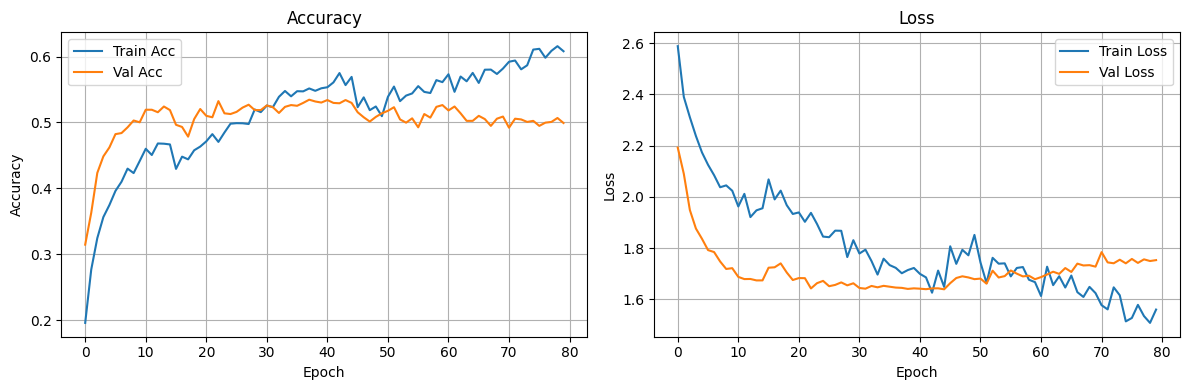

[SAVED] 학습 곡선: results/training_history_20260530_184704.png


C:\Users\rlaeh\AppData\Local\Temp\ipykernel_16180\2693833788.py:58: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rlaeh\AppData\Local\Temp\ipykernel_16180\2693833788.py:58: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rlaeh\AppData\Local\Temp\ipykernel_16180\2693833788.py:58: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rlaeh\AppData\Local\Temp\ipykernel_16180\2693833788.py:58: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rlaeh\AppData\Local\Temp\ipykernel_16180\2693833788.py:58: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rlaeh\AppData\Local\Temp\ipykernel_16180\2693833788.py:58: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from 

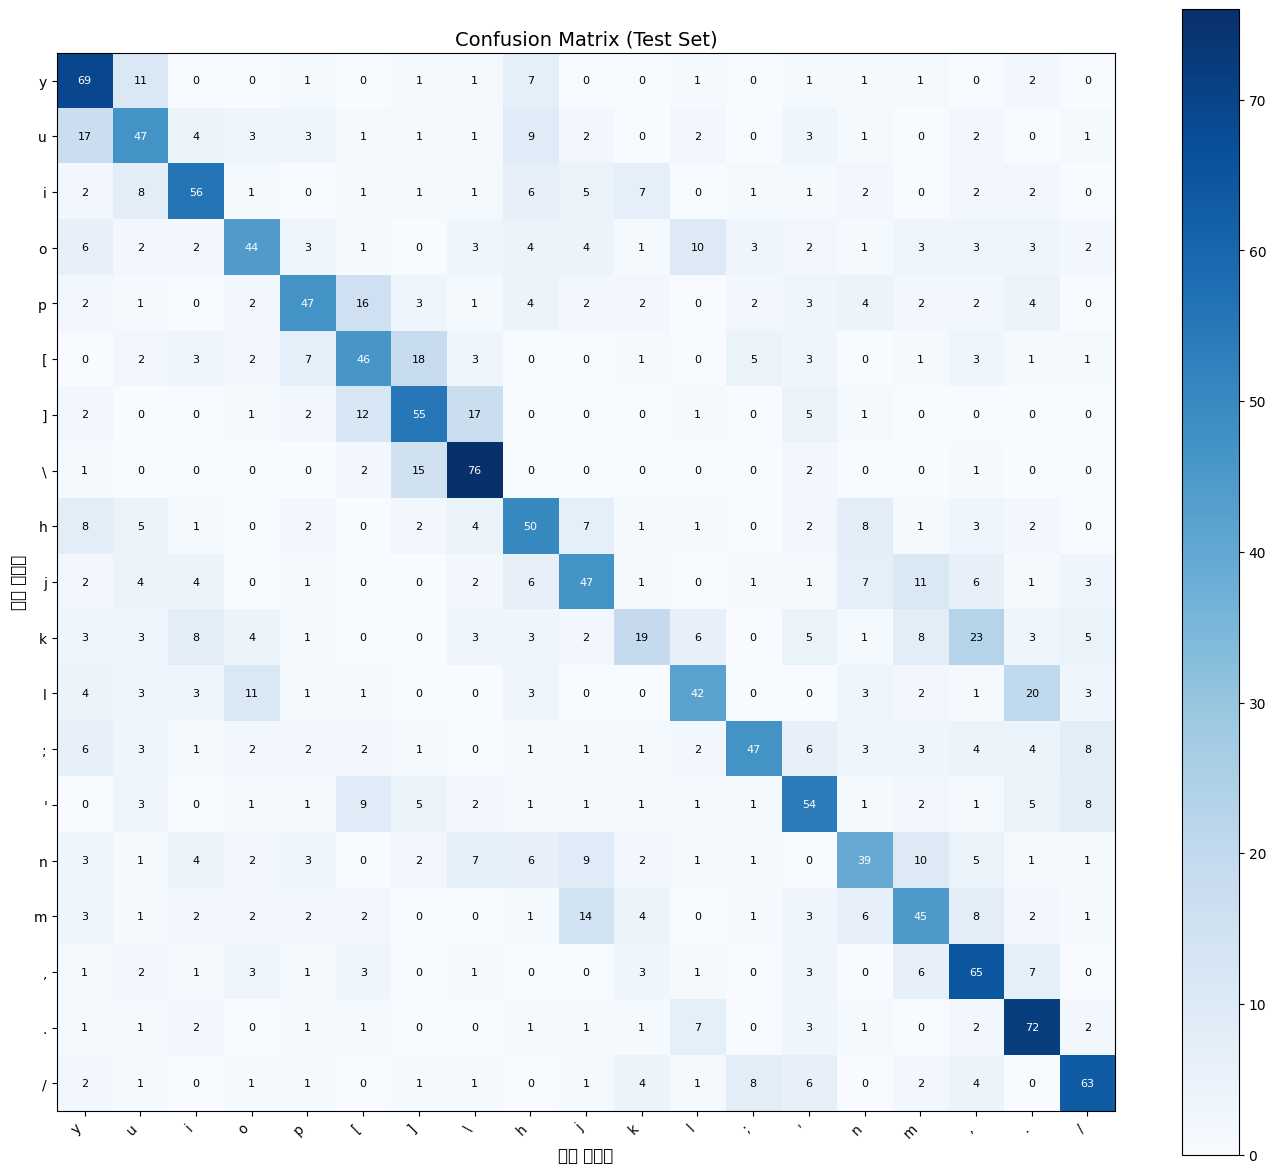

[SAVED] 혼동 행렬: results/confusion_matrix_20260530_184704.png
[SAVED] 텍스트 리포트: results/report_20260530_184704.txt
[SAVED] 학습 로그 CSV: results/training_log_20260530_184704.csv

[완료] 전체 분석 및 학습 파이프라인 처리가 완료되었습니다.


In [ ]:
try:
    if 'model' in locals():
        # 최고 성능 모델 가중치 로딩
        model.load_state_dict(torch.load('best_emg_model.pt', map_location=DEVICE, weights_only=True))
        
        # Test 셋 평가
        test_loss, test_acc = run_epoch(model, test_loader, criterion, None, scaler, DEVICE, is_train=False)
        print(f"\n[RESULT] Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

        # 결과 저장소 초기화
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        os.makedirs('results', exist_ok=True)

        inv_map     = {v: k for k, v in RIGHT_HAND_KEYS.items()}
        class_names = [inv_map[idx_to_label[i]] for i in range(NUM_CLASSES)]

        y_true, y_pred = get_predictions(model, test_loader, DEVICE)
        cm = confusion_matrix(y_true, y_pred)

        dataset_info = {
            'Train 샘플 수 (증강 후)': len(X_train),
            'Val 샘플 수             ': len(X_val),
            'Test 샘플 수            ': len(X_test),
        }

        # 시각화 및 리포트 저장
        plot_history(history, save_path=f'results/training_history_{timestamp}.png')
        plot_confusion_matrix(cm, class_names, save_path=f'results/confusion_matrix_{timestamp}.png')
        save_text_report(class_names, y_true, y_pred, test_loss, test_acc, history, dataset_info, save_path=f'results/report_{timestamp}.txt')

        # 학습 로그 CSV 저장
        df_log = pd.DataFrame({
            'epoch':      range(1, len(history['train_loss']) + 1),
            'train_loss': history['train_loss'],
            'val_loss':   history['val_loss'],
            'train_acc':  [round(a * 100, 2) for a in history['train_acc']],
            'val_acc':    [round(a * 100, 2) for a in history['val_acc']],
        })
        df_log.to_csv(f'results/training_log_{timestamp}.csv', index=False)
        print(f"[SAVED] 학습 로그 CSV: results/training_log_{timestamp}.csv")
        
        print("\n[완료] 전체 분석 및 학습 파이프라인 처리가 완료되었습니다.")

except Exception as e:
    print("평가 및 저장 과정 중 오류가 발생했습니다:", e)
